In [1]:
import numpy as np
import matplotlib.pyplot as pt

# Load the arrays stored inside the NPZ file.
data = np.load("flowers_data.npz")
view = data["X"]
Y_all = data["Y"].astype(int).reshape(-1)

print("Images:", view.shape)
print("Labels:", Y_all.shape)

# Shuffle images and labels together.
if view.shape[0] != Y_all.size:
    raise ValueError(f"Image count {view.shape[0]} does not match label count {Y_all.size}")
permutation = np.random.permutation(view.shape[0])
view_shuffled = view[permutation]
Y_shuffled = Y_all[permutation]

# Normalize and transpose so columns are individual images.
m = view_shuffled.shape[0]
X_all = (view_shuffled.reshape(m, -1) / 255.0).T
print("Features:", X_all.shape)

Images: (11197, 150, 150, 3)
Labels: (11197,)
Features: (67500, 11197)


In [2]:
# Split the normalized feature matrix into validation and training sets.
validation_size = min(1500, X_all.shape[1] // 5)
X_aside = X_all[:, :validation_size]
X_train = X_all[:, validation_size:]
Y_aside = Y_shuffled[:validation_size]
Y_train = Y_shuffled[validation_size:]

print("X_aside shape:", X_aside.shape)
print("X_train shape:", X_train.shape)
print("Number of classes:", np.unique(Y_shuffled).size)

flower_map = {
    "daisy": 0,
    "dandelion": 1,
    "rose": 2,
    "sunflower": 3,
    "tulip": 4,
    "bellflower": 5,
    "lotus": 6,
}

X_aside shape: (67500, 1500)
X_train shape: (67500, 9697)
Number of classes: 7


In [3]:
def parameters(input_size, hidden_size, class_count):
    W1 = np.random.randn(hidden_size, input_size) * np.sqrt(2.0 / input_size)
    b1 = np.zeros((hidden_size, 1))
    W2 = np.random.randn(class_count, hidden_size) * np.sqrt(2.0 / hidden_size)
    b2 = np.zeros((class_count, 1))
    return W1, b1, W2, b2


def ReLu(Z):
    return np.where(Z > 0, Z, 0.01 * Z)


def derivative_ReLU(Z):
    return np.where(Z > 0, 1.0, 0.01)


def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)


def forward_prop(W1, W2, b1, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2


def hot_encoding(Y, class_count):
    one_hot_Y = np.zeros((Y.size, class_count))
    one_hot_Y[np.arange(Y.size), Y.astype(int)] = 1
    return one_hot_Y.T


def back_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = hot_encoding(Y, W2.shape[0])

    dZ2 = A2 - one_hot_Y
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

    dZ1 = np.dot(W2.T, dZ2) * derivative_ReLU(Z1)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2


def updated_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

Iteration   0 | Training Accuracy: 12.75%
Iteration  10 | Training Accuracy: 14.44%
Iteration  20 | Training Accuracy: 22.83%
Iteration  30 | Training Accuracy: 18.19%
Iteration  40 | Training Accuracy: 28.21%
Iteration  50 | Training Accuracy: 25.36%
Iteration  60 | Training Accuracy: 32.94%
Iteration  70 | Training Accuracy: 34.13%
Iteration  80 | Training Accuracy: 36.29%
Iteration  90 | Training Accuracy: 41.16%
Iteration 100 | Training Accuracy: 39.57%
Iteration 110 | Training Accuracy: 42.72%
Iteration 120 | Training Accuracy: 44.86%
Iteration 130 | Training Accuracy: 45.25%
Iteration 140 | Training Accuracy: 44.26%
Iteration 150 | Training Accuracy: 43.99%
Iteration 160 | Training Accuracy: 46.19%
Iteration 170 | Training Accuracy: 45.95%
Iteration 180 | Training Accuracy: 46.62%
Iteration 190 | Training Accuracy: 47.07%
Iteration 200 | Training Accuracy: 45.47%
Iteration 210 | Training Accuracy: 48.27%
Iteration 220 | Training Accuracy: 48.46%
Iteration 230 | Training Accuracy:

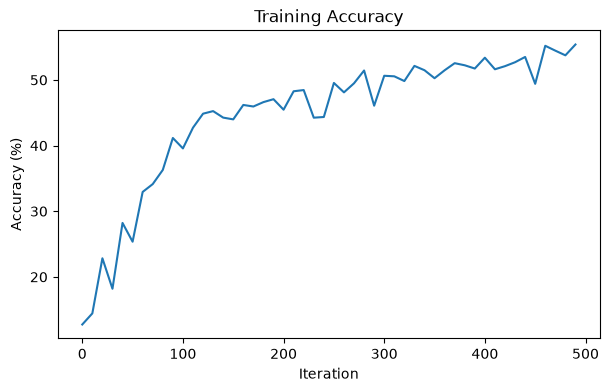

In [ ]:
def get_predictions(A2):
    return np.argmax(A2, axis=0)


def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size


# Run full-batch gradient descent.
def grad_descent(X, Y, alpha, iterations):
    accuracy_history = []
    iteration_history = []
    class_count = np.unique(Y).size
    W1, b1, W2, b2 = parameters(X.shape[0], hidden_size=128, class_count=class_count)

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, W2, b1, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = updated_parameters(
            W1, b1, W2, b2, dW1, db1, dW2, db2, alpha
        )

        if i % 10 == 0:
            predictions = get_predictions(A2)
            accuracy = get_accuracy(predictions, Y)
            print(f"Iteration {i:3d} | Training Accuracy: {accuracy * 100:.2f}%")
            accuracy_history.append(accuracy * 100)
            iteration_history.append(i)

    return W1, b1, W2, b2, iteration_history, accuracy_history


W1, b1, W2, b2, iteration_history, accuracy_history = grad_descent(
    X_train, Y_train, alpha=0.01, iterations=1000    
)

pt.figure(figsize=(7, 4))
pt.plot(iteration_history, accuracy_history)
pt.xlabel("Iteration")
pt.ylabel("Accuracy (%)")
pt.title("Training Accuracy")
pt.show()